# Main Energy Simulation Notebook

This notebook simulates the energy consumption for each track, calculates 
the State of Charge (SoC) each truck would have, and calculates the 
resulting load profiles for the freight forwarding locations.
 
Execution order:
 1. data/data_handling/data-aquisition.ipynb
 2. main_data_analysis.ipynb  
 3. main_energy_sim.ipynb (this notebook)

### Imports and Setup

In [16]:
# Enable automatic reloading of modules for development
%load_ext autoreload
%autoreload 2

# Standard library imports
import sys

# Third-party imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches 
import matplotlib.lines as mlines
import matplotlib.colors
import matplotlib.ticker as mticker

# Local imports
from utils.style_config import *

# Add energy_sim to Python path for custom module imports
sys.path.append('energy_sim')
import data_handling.data_processing as dp
import energy_sim.sequential_analysis as sq
import energy_sim.load_profile as lp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Style Parameters

In [17]:
# Configure matplotlib for LaTeX rendering and consistent styling
plt.rcParams.update({
    'text.usetex': True,                    # Enable LaTeX text rendering
    'font.family': 'sans-serif',            # Use sans-serif font family
    'font.sans-serif': 'Arial',             # Set Arial as primary sans-serif font
    'font.size': 12,                        # Set base font size to 12pt
    'text.latex.preamble': r'\usepackage{siunitx}'  # Load siunitx for units
})

### Scenario Parameters

In [18]:

# Define charging scenario parameters for different electrification strategies
# Each scenario represents different battery capacities and charging power levels
params_set = pd.DataFrame({
    'default': {
        'batt_cap': 572,                    # Battery capacity in kWh
        'dispatch': 'constant',             # Dispatch strategy
        'soc_min': 0.15,                    # Minimum State of Charge (15%)
        'soc_max': 0.9,                     # Maximum State of Charge (90%)
        'charging_powers': {
            'home base': 150,               # Home base charging power in kW
            'industrial area': 0            # Industrial area charging power in kW
        },
    },
    'big_batt': {
        'batt_cap': 798,                    # Larger battery capacity in kWh
        'dispatch': 'constant',             # Dispatch strategy
        'soc_min': 0.15,                    # Minimum State of Charge (15%)
        'soc_max': 0.9,                     # Maximum State of Charge (90%)
        'charging_powers': {
            'home base': 150,               # Home base charging power in kW
            'industrial area': 0            # Industrial area charging power in kW
        },
    },
    'destination': {
        'batt_cap': 572,                    # Battery capacity in kWh
        'dispatch': 'constant',             # Dispatch strategy
        'soc_min': 0.15,                    # Minimum State of Charge (15%)
        'soc_max': 0.9,                     # Maximum State of Charge (90%)
        'charging_powers': {
            'home base': 150,               # Home base charging power in kW
            'industrial area': 350          # Industrial area charging power in kW
        },
    },
    'low_home': {
        'batt_cap': 572,                    # Battery capacity in kWh
        'dispatch': 'constant',             # Dispatch strategy
        'soc_min': 0.15,                    # Minimum State of Charge (15%)
        'soc_max': 0.9,                     # Maximum State of Charge (90%)
        'charging_powers': {
            'home base': 50,                # Low home base charging power in kW
            'industrial area': 0            # Industrial area charging power in kW
        },
    },
    'high_home': {
        'batt_cap': 572,                    # Battery capacity in kWh
        'dispatch': 'constant',             # Dispatch strategy
        'soc_min': 0.15,                    # Minimum State of Charge (15%)
        'soc_max': 0.9,                     # Maximum State of Charge (90%)
        'charging_powers': {
            'home base': 350,               # High home base charging power in kW
            'industrial area': 0            # Industrial area charging power in kW
        },
    },
    'ultra_home': {
        'batt_cap': 572,                    # Battery capacity in kWh
        'dispatch': 'constant',             # Dispatch strategy
        'soc_min': 0.15,                    # Minimum State of Charge (15%)
        'soc_max': 0.9,                     # Maximum State of Charge (90%)
        'charging_powers': {
            'home base': 10000,             # Ultra-high home base charging power in kW
            'industrial area': 0            # Industrial area charging power in kW
        },
    }
})

# Display the scenario parameters for verification
# In Jupyter notebook: display(params_set)
print("Scenario parameters loaded successfully")

# Set default scenario for analysis
DEFAULT_SCENARIO = 'default'

Scenario parameters loaded successfully


## Energy Simulation Execution based on BET.OS script 

NOTE: The energy simulation takes approximately 24 hours to run and should
only be executed once. The results are saved as CSV files for subsequent use.
 
Execution steps:
 1. Run faulty_tracks() to identify tracks with missing data
    (saves results to mismatched_tracks.csv)
 2. Run run_energy_sim() to calculate energy consumption for each track
    (saves results to tracks_filtered_with_energy.csv)# 3. run_energy_sim() also creates zero_speed_tracks.csv for tracks without speed data

### One-time execution (commented out)

In [19]:
# Identify tracks with missing or faulty data
# faulty_tracks()

# Run the complete energy simulation
# trips_energy = run_energy_sim(override_mismatched_tracks=False)

# Clean and process the simulation results
# df_trip_energy = clean_energy_sim_data(trips=None)

### Data Loading (after one-time simulation execution)

In [20]:
# Load pre-processed track data with energy consumption calculations
df_trips = pd.read_csv('input/stations/tracks_filtered.csv', index_col='track_id')
df_trip_energy = pd.read_csv('output/csvs/tracks_with_energy.csv', index_col='track_id')

# Optional: Debug mode - limit data for faster processing
if False:  # Set to True for debugging with smaller dataset
    df_trip_energy = df_trip_energy.head(10000)  # Limit to first 10,000 tracks
    df_trips = df_trips.loc[df_trips.index.to_series().isin(df_trip_energy.index)]

# Convert timestamp columns to datetime with UTC timezone
df_trips['stop_time'] = pd.to_datetime(df_trips['stop_time'], format='ISO8601', utc=True)
df_trips['start_time'] = pd.to_datetime(df_trips['start_time'], format='ISO8601', utc=True)

# Process stops data by removing unnecessary columns for energy analysis
columns_to_drop = [
    'duration', 'max_speed_kmh', 'avg_speed_kmh', 'gross_vehicle_weight', 
    'total_mass_with_trailer', 'axle_class', 'avg_speed', 'max_speed', 
    'n_signal_loss', 'd_signal_loss', 'r_signal_loss', 'avg_hdop'
]
df_stops = dp.process_stops_data(df_trips.drop(columns=columns_to_drop))

# Combine tracks and stops data for energy analysis
df_occ_energy = sq.combine_tracks_and_stops(
    df_stops=df_stops, 
    df_tracks_with_energy=df_trip_energy
)

________________________________________________________________________________
[Memory] Calling data_handling.data_processing.process_stops_data...
process_stops_data(          vehicle_id  tour_id                       start_time  \
track_id                                                         
0                  1        0 2021-09-10 09:04:53.598000+00:00   
1                  1        0 2021-09-10 10:57:54.718000+00:00   
2                  1        0 2021-09-10 11:25:20.146000+00:00   
10                 1        2 2021-09-13 06:25:03.766000+00:00   
13                 1        2 2021-09-13 07:59:33.994000+00:00   
...              ...      ...                              ...   
151588           163    18999 2023-12-29 13:46:20.194000+00:00   
151589           163    18999 2024-01-04 10:37:11.793000+00:00   
151590           163    18999 2024-01-04...)
_______________________________________________process_stops_data - 0.2s, 0.0min
_____________________________________________

### Scenario Analysis 

In [21]:
# Initialize dictionaries to store results for each scenario
soc_results = {}           # Store State of Charge results per scenario
tours_energy_results = {}  # Store tour energy results per scenario
results = {}               # Store charging distribution results per scenario

# Iterate through each charging scenario
for scenario in params_set.columns:
    # Extract parameters for current scenario
    params = params_set[scenario].to_dict()
    
    # Print progress indicator
    print("")
    print(f"******************************")
    print(f"Running scenario: {scenario}")
    
    # Calculate State of Charge for trucks in this scenario
    df_soc = sq.truck_soc(df_activities=df_occ_energy, **params)
    
    # Evaluate charging distribution and energy requirements
    results_dict = sq.evaluate_charging_distribution(
        df_soc, 
        evaluate_per_fleet=False, 
        **params
    )
    results.update({scenario: results_dict})
    
    # Calculate and store tour energy results for this scenario
    df_tours_energy_scenario = dp.aggregate_tours(df_soc, energy=True)
    tours_energy_results[scenario] = df_tours_energy_scenario
    
    # Store State of Charge results for this scenario
    soc_results[scenario] = df_soc

# Convert results to DataFrame for easier analysis
df_results = pd.DataFrame(results).T


******************************
Running scenario: default
________________________________________________________________________________
[Memory] Calling energy_sim.sequential_analysis.truck_soc...
truck_soc(df_activities=       vehicle_id  tour_id                       start_time  \
0               1        0 2021-09-10 09:04:53.598000+00:00   
1               1        0 2021-09-10 10:07:57.395000+00:00   
2               1        0 2021-09-10 10:57:54.718000+00:00   
3               1        0 2021-09-10 11:13:53.221000+00:00   
4               1        0 2021-09-10 11:25:20.146000+00:00   
...           ...      ...                              ...   
85247         163    18999 2024-01-04 14:16:00.434000+00:00   
85248         163    18999 2024-01-04 15:26:41.892000+00:00   
85249         163    18999 2024-01-05 11:02:24.568000+00:00   
85250         163    18999 2024-01-05 11:37:38.462000+00:00   
85251  ..., batt_cap=572, dispatch='constant', soc_min=0.15, soc_max=0.9, charging_

### Charging Distribution Analysis 

Charging distribution analysis completed
\begin{table}
\caption{Distribution of charging energy per freight forwarder and occupation. The values are normalized to the total energy recharged per freight forwarder.}
\label{df_charging_per_fleet}
\begin{tabular}{lcc}
\toprule
occupation & driving & home base & industrial area \\
freight_forwarder &  &  &  \\
\midrule
1 & \SI{19.70}{\percent} & \SI{54.71}{\percent} & \SI{25.59}{\percent} \\
2 & \SI{0.25}{\percent} & \SI{96.39}{\percent} & \SI{3.36}{\percent} \\
3 & \SI{1.68}{\percent} & \SI{95.70}{\percent} & \SI{2.62}{\percent} \\
4 & \SI{25.56}{\percent} & \SI{35.84}{\percent} & \SI{38.60}{\percent} \\
5 & \SI{2.93}{\percent} & \SI{90.45}{\percent} & \SI{6.62}{\percent} \\
6 & \SI{14.86}{\percent} & \SI{68.50}{\percent} & \SI{16.65}{\percent} \\
\bottomrule
\end{tabular}
\end{table}



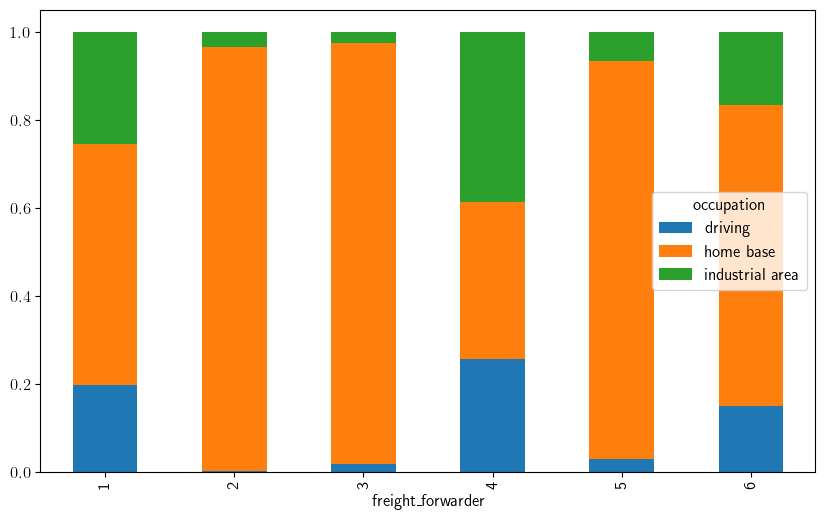

In [22]:
# Analyze charging energy distribution per freight forwarder and occupation type
# Focus on the 'destination' scenario which includes industrial charging
df_charging_per_fleet = (
    soc_results['destination']
    .groupby(['freight_forwarder', 'occupation'])
    .energy_recharged_kwh
    .sum()
    .unstack()
    .drop(columns=['other area', 'rest area', 'service area fuel'])
)

# Normalize charging energy to percentages per freight forwarder
df_charging_per_fleet = (df_charging_per_fleet.T / df_charging_per_fleet.T.sum()).T

# Create stacked bar plot of charging distribution
df_charging_per_fleet.plot.bar(stacked=True, figsize=(10, 6))

# Display the charging distribution data
# In Jupyter notebook: display(df_charging_per_fleet)
print("Charging distribution analysis completed")

# Generate LaTeX table for publication
print((100 * df_charging_per_fleet).to_latex(
    float_format="\\SI{%.2f}{\\percent}", 
    label="df_charging_per_fleet", 
    caption="Distribution of charging energy per freight forwarder and occupation. "
            "The values are normalized to the total energy recharged per freight forwarder.", 
    index=True, 
    column_format='l' + 'c' * (len(df_charging_per_fleet.columns) - 1)
))

### Scenario Comparision - Charging Location Proportions per Scenario

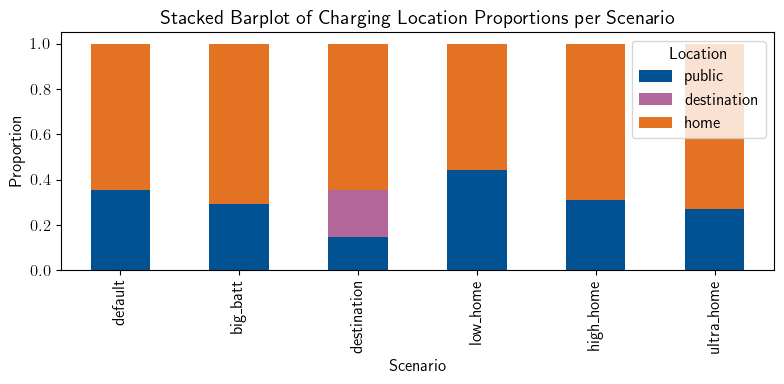

In [23]:
# Create stacked bar plot comparing charging locations across scenarios
df_results.plot(
    kind='bar',
    stacked=True,
    color=[line_colors['TUMBlue1'], line_colors['Purple'], line_colors['TUMOrange']],
    figsize=(8, 4)
)
plt.ylabel('Proportion')
plt.xlabel('Scenario')
plt.title('Stacked Barplot of Charging Location Proportions per Scenario')
plt.legend(title='Location')
plt.tight_layout()
plt.show()

# Save charging distribution results to CSV
df_results.to_csv('output/csvs/charging_distribution.csv')

In [24]:
# Extract parameters for the default scenario
params = params_set[DEFAULT_SCENARIO].to_dict()

# Calculate energy threshold based on battery capacity and SoC range
# This represents the maximum energy that can be stored in the battery
threshold = params['batt_cap'] * (params['soc_max'] - params['soc_min'])

### Tour Statistics Analysis

In [25]:
# NOTE: In contrast to df_tours, df_tours_energy also includes non-driving 
# activities between tracks. Thus, some additional parameters are included:
# 
# - Stop time: Stop time of the last track (equivalent to df_tours)
# - End time: Additionally includes time spent at home base after the tour's 
#   last track (i.e., = start time of the next tour)
# 
# - driving_duration: Sum of duration of all driving activities in the tour 
#   (equivalent to duration in df_tours)
# - duration: Time between start of tour's first track and end of its last 
#   activity (i.e., duration between start of tour and start of next tour)
# =============================================================================

# Aggregate tour data with energy information for the default scenario
df_tours_energy = dp.aggregate_tours(soc_results[DEFAULT_SCENARIO], energy=True)
# In Jupyter notebook: display(df_tours_energy)
print("Tour energy data aggregated successfully")

Tour energy data aggregated successfully


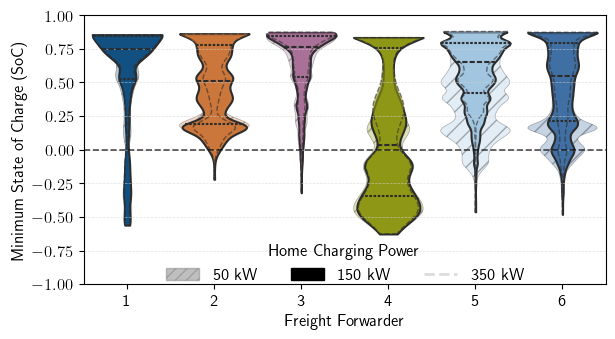

In [26]:
# =============================================================================
# SOC VIOLIN PLOTS BY FREIGHT FORWARDER
# =============================================================================

def plot_soc_min_violin(tours_energy_results, cut=-1):
    """
    Create a single violin plot showing the distribution of minimum State of Charge
    (soc_no_public_charging_min) for each freight forwarder.
    
    Overlays three scenarios per forwarder:
    - 50kW (light transparent with hatching)
    - 150kW (solid, default scenario)
    - 350kW (medium transparent with dashed lines)
    
    Parameters:
    -----------
    tours_energy_results : dict
        Dictionary containing tour energy results for each scenario
    cut : float, optional
        Cut parameter for violin plot (default: -1)
    """
    # Define scenarios to plot in order of visibility
    scenarios = ['low_home', 'default', 'high_home']
    
    # Extract and prepare data for the three scenarios
    dfs = []
    for scenario in scenarios:
        if scenario in tours_energy_results:
            df_sc = tours_energy_results[scenario].copy()
            df_sc['scenario'] = scenario  # Add scenario identifier column
            dfs.append(df_sc)
    
    # Validate that we have data to plot
    if not dfs:
        raise ValueError("No matching scenarios found in tours_energy_results.")
    
    # Combine all scenario data
    plot_df = pd.concat(dfs, ignore_index=True)
    
    # Create custom color palette with transparency for overlay effect
    alpha_map = {
        'low_home': 0.3,    # Light transparent for 50kW
        'default': 1.0,     # Solid for 150kW (default)
        'high_home': 0.6    # Medium transparent for 350kW
    }
    
    # Get unique freight forwarders and create adjusted color palette
    unique_ff = sorted(plot_df['freight_forwarder'].unique())
    palette_adjusted = {}
    
    for ff in unique_ff:
        base_color = palette_ff[ff]  # Get base color for this freight forwarder
        palette_adjusted[ff] = {}    # Nested dictionary for scenarios
        
        for scenario in scenarios:
            # Convert color to RGBA and adjust alpha
            rgba = list(matplotlib.colors.to_rgba(base_color))
            rgba[3] = alpha_map.get(scenario, 1.0)  # Set alpha value
            palette_adjusted[ff][scenario] = tuple(rgba)
    
    # Create violin plot with overlay effect
    plt.figure(figsize=(textwidth, h_169))
    
    for scenario in scenarios:
        # Filter data for current scenario
        df_sc = plot_df[plot_df['scenario'] == scenario]
        
        # Count collections before plotting to identify new ones
        num_col_before = len(plt.gca().collections)
        
        # Create violin plot for this scenario
        sns.violinplot(
            data=df_sc,
            x='freight_forwarder',
            y='soc_no_public_charging_min',
            hue='freight_forwarder',  # Use freight forwarder for color differentiation
            palette={ff: palette_adjusted[ff][scenario] for ff in unique_ff},
            inner='quartile' if scenario == 'default' else None,  # Show quartiles only for default
            cut=cut,
            linewidth=1.5 if scenario == 'default' else 1.0,  # Thicker lines for default
            bw_adjust=0.5,  # Bandwidth adjustment for smoothing
            dodge=False,    # Overlay instead of side-by-side placement
            legend=False,
            alpha=alpha_map.get(scenario, 1.0)  # Additional alpha for fill
        )
        
        # Apply special styling for low_home scenario (50kW)
        if scenario == 'low_home':
            for i in range(num_col_before, len(plt.gca().collections)):
                plt.gca().collections[i].set_hatch('//')  # Add hatching
                plt.gca().collections[i].set_edgecolor('black')  # Black edges
                plt.gca().collections[i].set_linewidth(0.5)  # Thin lines
        
        # Apply special styling for high_home scenario (350kW)
        if scenario == 'high_home':
            for i in range(num_col_before, len(plt.gca().collections)):
                plt.gca().collections[i].set_linestyle('--')  # Dashed lines
                plt.gca().collections[i].set_linewidth(1.0)   # Medium line width
    
    # Add grid for better readability
    plt.grid(True, axis='y', linestyle='--', linewidth=0.5, 
             color='lightgrey', alpha=0.7)
    
    # Set labels and limits
    plt.xlabel('Freight Forwarder')
    plt.ylabel('Minimum State of Charge (SoC)')
    plt.ylim(cut, 1)
    
    # Set x-axis ticks
    plt.xticks(
        ticks=range(len(unique_ff)),
        labels=unique_ff
    )
    
    # Add threshold line at y=0 to indicate clipped area
    plt.axhline(y=0, linestyle='--', color='black', alpha=0.7, 
                linewidth=1.2, label='0 SoC Threshold (clipped below)')
    
    # Create custom legend
    legend_colors = {
        'low_home': 'gray',      # Darker gray for 50kW
        'default': 'black',      # Strong black for 150kW
        'high_home': 'lightgray' # Light gray for 350kW
    }
    
    power_map = {
        'low_home': '50', 
        'default': '150', 
        'high_home': '350'
    }
    
    # Create legend handles with appropriate styling
    handles = []
    for scenario in scenarios:
        if scenario != 'high_home':
            # Create patch for low_home and default scenarios
            handle = mpatches.Patch(
                color=legend_colors[scenario], 
                alpha=min(1.0, alpha_map[scenario] + 0.2), 
                hatch='///' if scenario == 'low_home' else None, 
                label=f'{power_map[scenario]} kW'
            )
        else:
            # Create line for high_home scenario
            handle = mlines.Line2D(
                [], [], 
                color=legend_colors[scenario], 
                alpha=min(1.0, alpha_map[scenario] + 0.2), 
                linestyle='--', 
                linewidth=2, 
                label=f'{power_map[scenario]} kW'
            )
        handles.append(handle)
    
    # Add legend at bottom
    plt.legend(
        handles=handles, 
        title='Home Charging Power', 
        loc='lower center', 
        bbox_to_anchor=(0.5, -0.02),
        ncol=3, 
        borderaxespad=0., 
        frameon=False
    )
    
    # Finalize plot
    plt.tight_layout()
    plt.savefig('output/figures/energy/soc_min_violin.pdf')

# Generate the SOC violin plot
plot_soc_min_violin(tours_energy_results, cut=-1)

## Charging Energy Demand per Home Base

In [27]:
# NOTE: Most critical for freight forwarder 4, where we have a representative 
# sample of 10% of all of the freight forwarder's trucks. Daily load profiles 
# would be 10x of these results.
# 
# Analysis shows that 90/135 or 66% of all recorded days could not be served 
# with one transformer even if we assume an even load profile throughout the day.
# Maximum recharge in a day with 1 transformer = 630 kW * 24h = 15,120 kWh
# =============================================================================

# Calculate daily energy demands for each home base using the default scenario
daily_demands = dp.daily_energy_demands(
    df_tours_energy, 
    threshold, 
    params['charging_powers']
)

# Display first few rows of daily demands for verification
print(daily_demands.head())

          day energy_demand_kwh  cid  freight_forwarder
0  2021-09-07               0.0    0                  1
1  2021-09-08              -0.0    0                  1
2  2021-09-09               0.0    0                  1
3  2021-09-10         19.473826    0                  1
4  2021-09-12              -0.0    0                  1


In [28]:
# =============================================================================
# WEEKLY ENERGY DEMAND BOXPLOT
# =============================================================================

def plot_weekly_energy_demand_boxplot(df_loads):
    """
    Creates a comprehensive figure with a central boxplot showing all home bases' 
    energy demand together at the top, and individual plots for each home base 
    (CID) below.
    
    Parameters:
    -----------
    df_loads : DataFrame
        DataFrame containing daily energy demand data with columns:
        - day: datetime column
        - energy_demand_kwh: daily energy demand in kWh
        - cid: home base identifier
        - freight_forwarder: freight forwarder identifier
    """
    # Convert day column to datetime and extract weekday information
    df_loads['day'] = pd.to_datetime(df_loads['day'])
    df_loads['weekday'] = df_loads['day'].dt.weekday  # 0 = Monday, 6 = Sunday

    # Create subplots with a 3 column x 5 row grid (15 subplots total)
    fig = plt.figure(figsize=(textwidth, h_169))
    
    # Add a GridSpec with 5 rows and 3 columns, with different height ratios
    gs = fig.add_gridspec(5, 3, height_ratios=[2, 1, 1, 1, 1])
    
    # Add the central plot at the top, spanning all columns
    central_ax = fig.add_subplot(gs[0, :])
    
    # Create the individual CID axes for the bottom 4 rows
    axes = []
    for i in range(1, 5):  # Rows 1-4
        for j in range(3):  # 3 columns
            ax = fig.add_subplot(gs[i, j])
            axes.append(ax)
    
    # Get unique CIDs for individual plots
    cids = sorted(df_loads['cid'].unique())
    
    # Prepare data for the central plot (all home bases combined)
    all_boxplot_data = []
    all_weekday_labels = []
    all_weekday_numbers = []  # Store actual weekday numbers
    
    # Collect data for each weekday
    for weekday in range(7):
        weekday_data = df_loads[df_loads['weekday'] == weekday]['energy_demand_kwh'].tolist()
        if len(weekday_data) > 0:  # Only add if there's data for this weekday
            all_boxplot_data.append(weekday_data)
            all_weekday_labels.append(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][weekday])
            all_weekday_numbers.append(weekday)
    
    # Add combined data (all weekdays together) for overall comparison
    all_avg_data = df_loads['energy_demand_kwh'].tolist()
    all_boxplot_data.append(all_avg_data)
    all_weekday_labels.append('Combined')
    all_weekday_numbers.append('Combined')
    
    # Create central boxplot with all data
    scaling_factor = textwidth / 16  # Scale elements based on figure width
    bp_central = central_ax.boxplot(
        all_boxplot_data,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        meanprops=dict(
            color=colors['TUMGreen3'], 
            linestyle='--', 
            linewidth=1.5 * scaling_factor
        ),
        medianprops=dict(
            color=colors['TUMOrange'], 
            linewidth=1.5 * scaling_factor
        ),
        showfliers=True,
        flierprops=dict(
            marker='o', 
            color='red', 
            alpha=0.5, 
            markersize=3
        ),
        whiskerprops=dict(
            color=colors['TUMBlack'], 
            linewidth=0.8 * scaling_factor
        ),
        capprops=dict(
            color=colors['TUMBlack'], 
            linewidth=0.8 * scaling_factor
        ),
        widths=0.55 * scaling_factor,
        positions=range(len(all_boxplot_data)),
        labels=all_weekday_labels
    )
    
    # Style the central boxplot
    central_ax.set_title(
        'Energy Demand Distribution by Weekday (All Home Bases Combined)', 
        fontsize=15, 
        fontweight='bold'
    )
    central_ax.set_ylabel('Energy Demand / kWh', fontsize=15)
    central_ax.tick_params(axis='both', which='major', labelsize=15)
    central_ax.grid(True, which='both', axis='y', linestyle='--', 
                   linewidth=0.5, color='lightgrey', alpha=0.7)
    central_ax.set_ylim(bottom=0)
    
    # Customize spines for professional appearance
    for spine in central_ax.spines.values():
        spine.set_edgecolor(colors['TUMBlack'])
        spine.set_linewidth(0.8 * scaling_factor)
    
    # Assign colors to the boxplots based on weekday or 'Combined'
    for j, (box, weekday_or_combined) in enumerate(zip(bp_central['boxes'], all_weekday_numbers)):
        box.set_facecolor(palette_weekdays[weekday_or_combined])
        # Add thicker border to the average box to make it stand out
        if weekday_or_combined == 'Combined':
            box.set(linewidth=2.0 * scaling_factor)
    
    # Process each CID for individual plots
    for i, cid in enumerate(cids):
        if i >= len(axes):
            break
            
        # Filter data for current CID
        cid_data = df_loads[df_loads['cid'] == cid]
        
        # Get the freight forwarder for this CID
        ff = cid_data['freight_forwarder'].iloc[0] if not cid_data.empty else "Unknown"
        
        # Calculate and print daily energy demand statistics per home base
        print(f"\nHome Base CID {cid} - Daily Energy Demand:")
        weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        daily_stats = cid_data.groupby('weekday')['energy_demand_kwh'].agg(['mean', 'std', 'median', 'count']).reset_index()
        daily_stats['weekday_name'] = daily_stats['weekday'].apply(lambda x: weekday_names[x])
        print(daily_stats[['weekday_name', 'mean', 'std', 'median', 'count']])
        print(f"Overall mean: {cid_data['energy_demand_kwh'].mean():.2f} kWh")
        
        # Prepare boxplot data with only available weekdays
        boxplot_data = []
        weekday_labels = []
        weekday_numbers = []  # Store actual weekday numbers
        
        for weekday in range(7):
            weekday_data = cid_data[cid_data['weekday'] == weekday]['energy_demand_kwh'].tolist()
            if len(weekday_data) > 0:  # Only add if there's data for this weekday
                boxplot_data.append(weekday_data)
                weekday_labels.append(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][weekday])
                weekday_numbers.append(weekday)
        
        # Create boxplot for this CID
        bp = axes[i].boxplot(
            boxplot_data,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            meanprops=dict(
                color=colors['TUMGreen3'], 
                linestyle='--', 
                linewidth=1.5 * scaling_factor
            ),
            medianprops=dict(
                color=colors['TUMOrange'], 
                linewidth=1.5 * scaling_factor
            ),
            showfliers=True,
            flierprops=dict(
                marker='o', 
                color='red', 
                alpha=0.5, 
                markersize=3
            ),
            whiskerprops=dict(
                color=colors['TUMBlack'], 
                linewidth=0.8 * scaling_factor
            ),
            capprops=dict(
                color=colors['TUMBlack'], 
                linewidth=0.8 * scaling_factor
            ),
            widths=0.55 * scaling_factor,
            positions=range(len(boxplot_data)),
            labels=weekday_labels
        )
        
        # Add statistics text box
        mean_val = cid_data['energy_demand_kwh'].mean()
        std_val = cid_data['energy_demand_kwh'].std()
        median_val = cid_data['energy_demand_kwh'].median()
        
        stats_text = f'Mean: {mean_val:.1f} kWh\nStd: {std_val:.1f} kWh\nMedian: {median_val:.1f} kWh'
        axes[i].text(
            0.02, 0.98, stats_text, 
            transform=axes[i].transAxes, 
            ha='left', va='top',
            fontsize=9, 
            bbox=dict(
                boxstyle='round', 
                pad=0.3 * scaling_factor, 
                facecolor=colors['TUMWhite'], 
                edgecolor=colors['TUMOrange'], 
                alpha=0.9
            )
        )
        
        # Assign colors to the boxplots based on weekday
        for j, (box, weekday_or_combined) in enumerate(zip(bp['boxes'], weekday_numbers)):
            box.set_facecolor(palette_weekdays[weekday_or_combined])
            # Add thicker border to make it stand out
            if weekday_or_combined == 'Combined':
                box.set(linewidth=2.0 * scaling_factor)
        
        # Set title for each subplot with both freight forwarder and CID
        axes[i].set_title(f'Freight Forwarder {ff} - Home Base CID {cid}')
        
        # Add grid for better readability
        axes[i].grid(True, which='both', axis='y', linestyle='--', 
                    linewidth=0.5, color='lightgrey', alpha=0.7)
        
        # Set y-axis limit
        axes[i].set_ylim(bottom=0)
        
        # Customize spines for professional appearance
        for spine in axes[i].spines.values():
            spine.set_edgecolor(colors['TUMBlack'])
            spine.set_linewidth(0.8 * scaling_factor)
    
    # Remove any empty subplots if there are fewer than 14 CIDs
    for i in range(len(cids), len(axes)):
        fig.delaxes(axes[i])
    
    # Add common y-axis label
    fig.text(0.01, 0.5, 'Energy Demand / kWh', ha='center', va='center', 
             rotation='vertical')

    # Finalize layout
    plt.tight_layout(rect=[0.02, 0.03, 1, 0.95])  # Adjust for common labels
    
    # Save and display the plot
    plt.savefig('output/figures/energy/home_base_weekday_energy_boxplots.pdf', 
                bbox_inches='tight')
    plt.show()

# Generate the weekly energy demand boxplot
# plot_weekly_energy_demand_boxplot(daily_demands) 

## Create Load Profiles

In [29]:
# Initialize DataFrames to store charging statistics and load profiles
df_charging_stats = pd.DataFrame()
df_load_profiles = pd.DataFrame()

# Calculate load profiles for each charging scenario
for scenario in params_set.columns:
    # Extract parameters for current scenario
    params = params_set[scenario].to_dict()
    print(f"Calculating load profiles for scenario: {scenario}")
    
    # Calculate charging load profiles with 630 kW threshold
    lp_, _, charging_stats = lp.calculate_charging_load_profiles(
        soc_results[scenario], 
        charging_power=params['charging_powers']['home base'], 
        load_threshold=630
    )
    
    # Add scenario identifier to load profiles
    lp_['scenario'] = scenario
    df_load_profiles = pd.concat([df_load_profiles, lp_.reset_index()], axis=0)

    # Process charging statistics (convert dict of dicts to DataFrame)
    df_stats = pd.DataFrame.from_dict(charging_stats, orient='index')
    df_stats['scenario'] = scenario
    df_charging_stats = pd.concat([df_charging_stats, df_stats.reset_index(names='cid')], axis=0)

# Display results for verification
# In Jupyter notebook: display(df_charging_stats)
# In Jupyter notebook: display(df_load_profiles)
print("Load profiles and charging statistics calculated successfully")

# Optional: Display specific scenario statistics
# display(df_charging_stats[df_charging_stats['scenario'] == 'big_batt'])

Calculating load profiles for scenario: default
Calculating load profiles for scenario: big_batt
Calculating load profiles for scenario: destination
Calculating load profiles for scenario: low_home
Calculating load profiles for scenario: high_home
Calculating load profiles for scenario: ultra_home
Load profiles and charging statistics calculated successfully


Zoom max plot saved successfully!
Zoom average plot saved successfully!


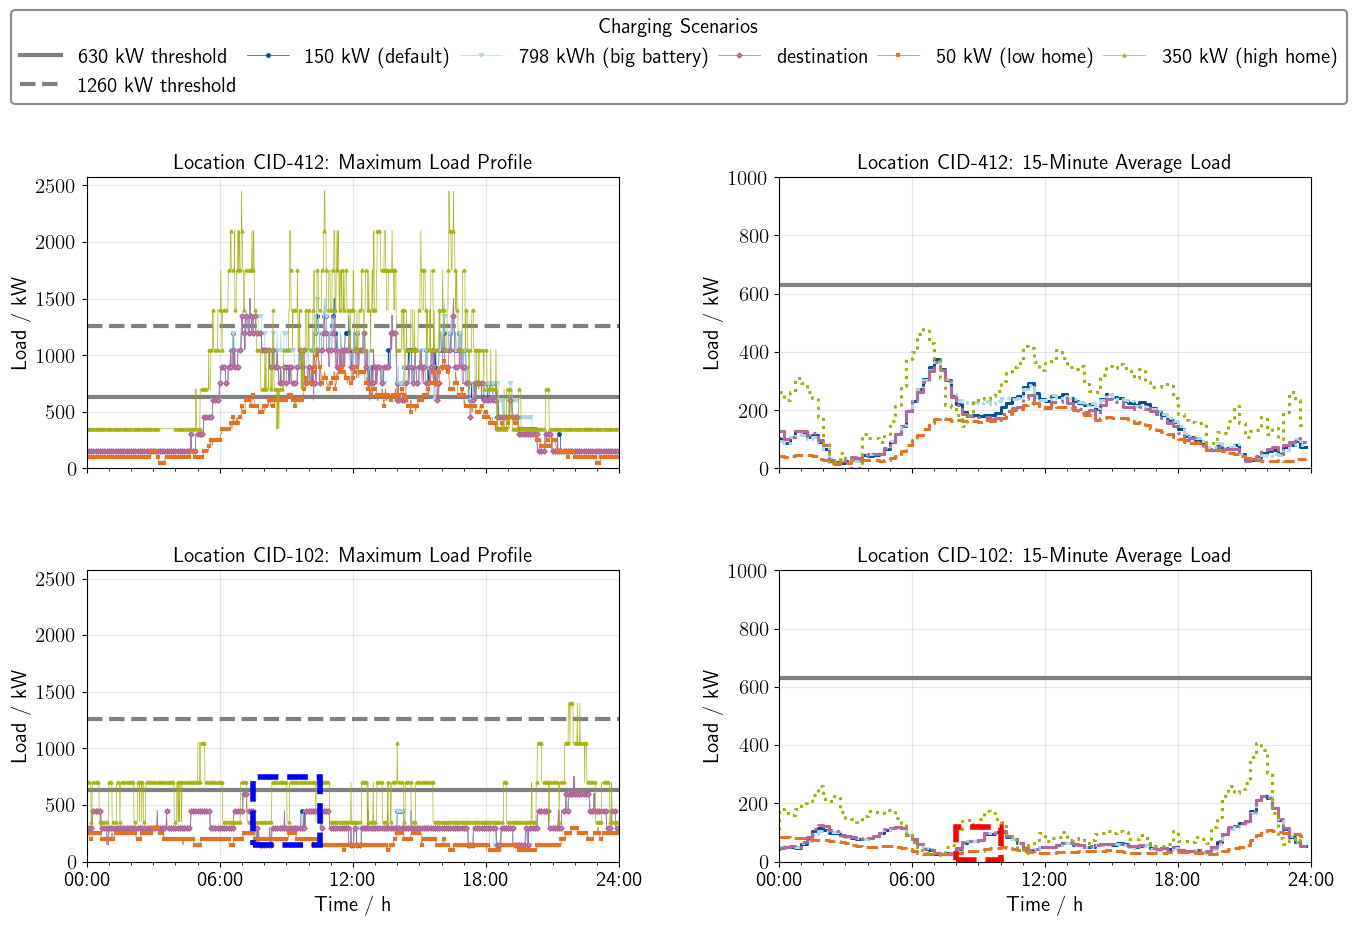

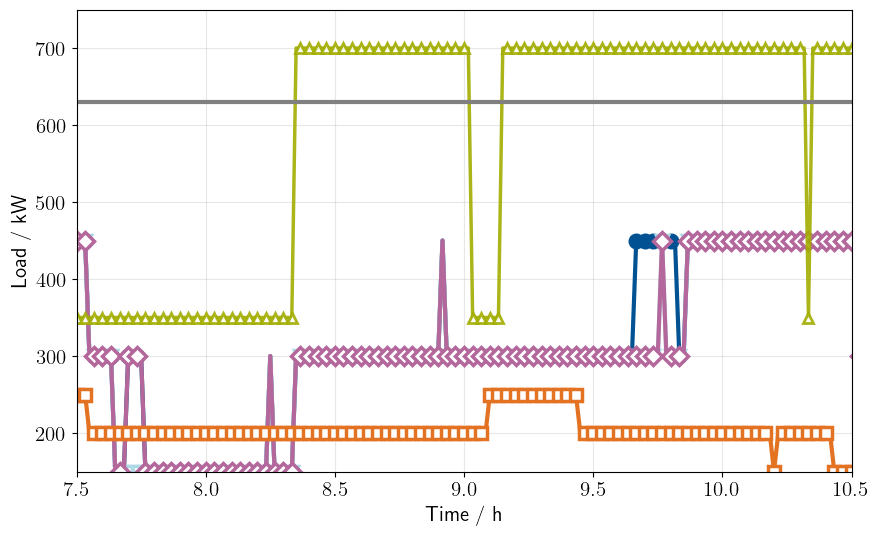

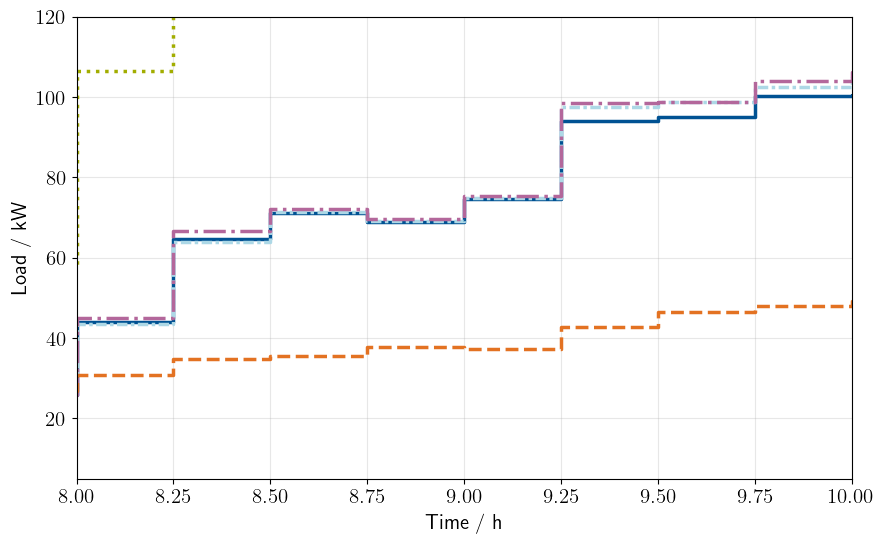

C:\Users\ge56wuh\AppData\Local\Temp\ipykernel_21824\3998241646.py:526: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_zoom_max.show()  # Show max zoom plot
C:\Users\ge56wuh\AppData\Local\Temp\ipykernel_21824\3998241646.py:529: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_zoom_avg.show()  # Show average zoom plot


In [30]:
# =============================================================================
# LOAD PROFILE VISUALIZATION FOR SELECTED LOCATIONS
# =============================================================================

# Define selected customer IDs (CIDs) for detailed analysis
selected_cids = [412, 102]

def plot_load_profiles_4plots(load_profiles, selected_cids):
    """
    Create a comprehensive 4-plot figure showing load profiles for selected locations.
    
    Layout:
    - Left column: Maximum load profiles per location (CID)
    - Right column: 15-minute average load per location (CID)
    
    Features:
    - Uses freight forwarder color palette for consistency
    - Scientific axis labels with proper units
    - Professional styling with 15pt font sizes
    - Gray threshold lines at 630 kW and 1260 kW
    
    Parameters:
    -----------
    load_profiles : DataFrame
        DataFrame containing load profile data with time index and scenario column
    selected_cids : list
        List of customer IDs (CIDs) to plot
    """
    # Configure LaTeX rendering for professional mathematical notation
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    plt.rcParams.update({'font.size': 15})  # Global font size 15

    # Use freight forwarder color palette from style configuration
    colors_plot = [palette_ff[1], palette_ff[2], palette_ff[3], palette_ff[4], palette_ff[5], palette_ff[6]]
    
    # Manual scenario names for clear legend labels
    scenario_names_manual = {
        'default': '150 kW (default)',
        'low_home': '50 kW (low home)',
        'high_home': '350 kW (high home)', 
        'destination': 'destination',
        'big_batt': ' 798 kWh (big battery)',
        'ultra_home': 'ultra home'
    }
    
    # Define scenario colors using freight forwarder palette
    scenario_colors = {
        'default': colors_plot[0],      # TUMBlue1
        'low_home': colors_plot[1],     # TUMOrange
        'high_home': colors_plot[3],    # TUMGreen3
        'destination': colors_plot[2],  # Purple
        'big_batt': 'lightblue',        # Light blue for large battery scenario
        'ultra_home': colors_plot[4]    # TUMBlue4
    }
    
    # Define markers for maximum load profiles (different shapes for each scenario)
    markers_scenarios = {
        'default': 'o',      # Circle
        'low_home': 's',     # Square
        'high_home': '^',    # Triangle up
        'destination': 'D',  # Diamond
        'big_batt': 'v',     # Triangle down
        'ultra_home': 'p'    # Pentagon
    }
    
    # Define marker fill patterns (filled vs. unfilled)
    marker_fill = {
        'default': 'full',        # Filled marker
        'low_home': 'none',       # Empty marker
        'high_home': 'none',      # Empty marker (unfilled)
        'destination': 'none',    # Empty marker
        'big_batt': 'full',       # Filled marker for light blue
        'ultra_home': 'none'      # Empty marker
    }
    
    # Gray colors for threshold lines
    threshold_colors = {
        'threshold': 'gray',      # Gray for 630 kW threshold
        'threshold2': 'gray'      # Gray for 1260 kW threshold
    }
    
    # Line styles for average load plots (different patterns for each scenario)
    linestyles_scenarios = {
        'default': '-',           # Solid line
        'low_home': '--',         # Dashed line
        'high_home': ':',         # Dotted line
        'destination': '-.',      # Dash-dot line
        'big_batt': (0, (3, 1, 1, 1)),  # Custom dash pattern
        'ultra_home': (0, (5, 2))        # Custom dash pattern
    }
    
    # Create figure with optimized layout (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(textwidth * 2.5, h_169 * 2.5), sharex='col')
    scenarios = load_profiles['scenario'].unique()
    
    # Calculate global maximum for consistent y-axis scaling across max plots
    global_max = 0
    for scenario in scenarios:
        if scenario == 'ultra_home':  # Skip ultra_home scenario
            continue
        df_scenario = load_profiles[load_profiles['scenario'] == scenario].copy()
        if 'time_' in df_scenario.columns:
            df_scenario.set_index('time_', inplace=True)
        
        # Find maximum load across all selected CIDs for this scenario
        for cid in selected_cids:
            if cid in df_scenario.columns:
                df_cid = df_scenario[[cid]].copy()
                df_cid = df_cid[df_cid[cid] > 0]  # Only consider positive loads
                if not df_cid.empty:
                    df_cid['time_of_day'] = df_cid.index.time
                    minute_max = df_cid.groupby('time_of_day')[cid].max()
                    max_load = minute_max.max() if not minute_max.empty else 0
                    global_max = max(global_max, max_load)
    
    # Set scaling for max plots with 5% margin
    global_max = global_max * 1.05
    
    # Create plots for each selected CID
    for i, cid in enumerate(selected_cids):
        # LEFT PLOT: Maximum load profiles
        ax_left = axes[i, 0]
        
        # Add threshold lines
        ax_left.axhline(630, color=threshold_colors['threshold'], lw=3, label='630 kW threshold')
        ax_left.axhline(1260, color=threshold_colors['threshold2'], ls='--', lw=3, label='1260 kW threshold')
        
        # Configure plot appearance
        ax_left.set_title(f'Location CID-{cid}: Maximum Load Profile', fontsize=15, fontweight='bold')
        ax_left.set_xticks(range(0, 25, 6))  # Major ticks every 6 hours
        ax_left.xaxis.set_minor_locator(mticker.FixedLocator(range(0, 25, 1)))  # Minor ticks every hour
        ax_left.set_xticklabels(['00:00', '06:00', '12:00', '18:00', '24:00'], fontsize=15)
        ax_left.set_xlim(0, 24)
        ax_left.set_ylim(0, global_max)
        ax_left.set_ylabel('Load / kW', fontsize=15)
        ax_left.tick_params(axis='both', which='major', labelsize=15)
        ax_left.grid('on', alpha=0.3)
        
        # Plot maximum load profiles for each scenario
        for scenario in scenarios:
            if scenario == 'ultra_home':  # Skip ultra_home scenario
                continue
            df_cid = load_profiles[load_profiles['scenario'] == scenario].copy()
            if cid not in df_cid.columns:
                continue
            if 'time_' in df_cid.columns:
                df_cid.set_index('time_', inplace=True)
            df_cid = df_cid[[cid]].copy()
            df_cid = df_cid[df_cid[cid] > 0]  # Only consider positive loads
            if not df_cid.empty:
                df_cid['time_of_day'] = df_cid.index.time
                minute_max = df_cid.groupby('time_of_day')[cid].max()
                minute_max_hours = minute_max.index.map(lambda t: t.hour + t.minute / 60 + t.second / 3600)
                
                # Apply different styling for high_home scenario
                if scenario == 'high_home':
                    ax_left.plot(minute_max_hours, minute_max.values, 
                                 label=f'{scenario_names_manual[scenario]}',
                                 lw=0.5,  # Very thin line
                                 color=scenario_colors[scenario],
                                 linestyle='-',
                                 marker=markers_scenarios[scenario],
                                 markersize=2,
                                 markevery=6,  # Show marker every 6th point
                                 alpha=0.9,
                                 markerfacecolor='white' if marker_fill[scenario] == 'none' else scenario_colors[scenario],
                                 markeredgecolor=scenario_colors[scenario],
                                 markeredgewidth=1.2)
                else:
                    ax_left.plot(minute_max_hours, minute_max.values, 
                                 label=f'{scenario_names_manual[scenario]}',
                                 lw=0.5,  # Very thin line
                                 color=scenario_colors[scenario],
                                 linestyle='-',
                                 marker=markers_scenarios[scenario],
                                 markersize=2,
                                 markevery=6,  # Show marker every 6th point
                                 markerfacecolor='white' if marker_fill[scenario] == 'none' else scenario_colors[scenario],
                                 markeredgecolor=scenario_colors[scenario],
                                 markeredgewidth=1.5)
        
        # RIGHT PLOT: 15-minute average load profiles
        ax_right = axes[i, 1]
        
        # Add threshold lines
        ax_right.axhline(630, color=threshold_colors['threshold'], lw=3, label='630 kW threshold')
        ax_right.axhline(1260, color=threshold_colors['threshold2'], ls='--', lw=3, label='1260 kW threshold')
        
        # Configure plot appearance
        ax_right.set_title(f'Location CID-{cid}: 15-Minute Average Load', fontsize=15, fontweight='bold')
        ax_right.set_xticks(range(0, 25, 6))  # Major ticks every 6 hours
        ax_right.xaxis.set_minor_locator(mticker.FixedLocator(range(0, 25, 1)))  # Minor ticks every hour
        ax_right.set_xticklabels(['00:00', '06:00', '12:00', '18:00', '24:00'], fontsize=15)
        ax_right.set_xlim(0, 24)
        ax_right.set_ylim(0, 1000)  # Fixed y-limit for average plots
        ax_right.set_ylabel('Load / kW', fontsize=15)
        ax_right.tick_params(axis='both', which='major', labelsize=15)
        ax_right.grid('on', alpha=0.3)
        
        # Plot 15-minute average load profiles for each scenario
        for scenario in scenarios:
            if scenario == 'ultra_home':  # Skip ultra_home scenario
                continue
            df = load_profiles.loc[load_profiles.scenario==scenario,[cid,]]
            df['date'] = df.index.date
            df['15min'] = df.index.floor('15min')  # Round to 15-minute intervals
            
            # Filter out dates with zero energy consumption
            date_nonzero_energy = df.groupby('date')[cid].sum().gt(0)
            df = df.loc[df['date'].isin(date_nonzero_energy[date_nonzero_energy].index)]
            
            # Calculate 15-minute average loads
            df_15min_load = df.groupby('15min')[cid].mean()
            plot_data = df_15min_load.groupby(df_15min_load.index.time).agg(['min', 'mean', 'max', 'median'])
            plot_data['hour'] = plot_data.index.map(lambda t: t.hour + t.minute / 60 + t.second / 3600)
            
            # Create step plot for average load
            ax_right.step(x=plot_data.hour, y=plot_data['mean'], 
                          label=f'{scenario_names_manual[scenario]}',
                          lw=2.2,
                          color=scenario_colors[scenario],
                          linestyle=linestyles_scenarios[scenario])
    
    # Add x-axis labels for bottom plots
    axes[1, 0].set_xlabel('Time / h', fontsize=15, fontweight='bold')
    axes[1, 1].set_xlabel('Time / h', fontsize=15, fontweight='bold')
    
    # Optimize layout with increased spacing between subplots
    plt.subplots_adjust(hspace=0.35, wspace=0.3)
    
    # Create professional legend with rectangle frame
    handles, labels = axes[0, 0].get_legend_handles_labels()
    legend = fig.legend(handles, labels, loc='upper center', title='Charging Scenarios', 
            bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=15, title_fontsize=15, 
            frameon=True, columnspacing=0.4)
    
    # Style the legend frame
    legend.get_frame().set_edgecolor('gray')
    legend.get_frame().set_linewidth(1.5)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    return axes

def add_manual_zoom_area(ax, x_range=(8.0, 10.0), y_range=(300, 500), color='red'):
    """
    Draw a manual zoom area rectangle with professional styling.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes to add the zoom area to
    x_range : tuple
        (x_min, x_max) range for the zoom area
    y_range : tuple
        (y_min, y_max) range for the zoom area
    color : str
        Color of the zoom area rectangle
        
    Returns:
    --------
    matplotlib.patches.Rectangle
        The created rectangle patch
    """
    rect = plt.Rectangle((x_range[0], y_range[0]), 
                        x_range[1] - x_range[0], 
                        y_range[1] - y_range[0],
                        fill=False, edgecolor=color, linewidth=4, linestyle='--', zorder=10)
    ax.add_patch(rect)
    return rect

def create_zoom_view(load_profiles, selected_cids, cid_index, plot_type, x_range, y_range, 
                    scenario_colors, markers_scenarios, marker_fill, linestyles_scenarios, 
                    threshold_colors, scenario_names):
    """
    Create a magnified view of a specific area with freight forwarder colors and scientific labels.
    
    Parameters:
    -----------
    load_profiles : DataFrame
        DataFrame containing load profile data
    selected_cids : list
        List of selected customer IDs
    cid_index : int
        Index of the CID in selected_cids to create zoom view for
    plot_type : str
        Type of plot ('max' or 'average')
    x_range : tuple
        (x_min, x_max) range for the zoom view
    y_range : tuple
        (y_min, y_max) range for the zoom view
    scenario_colors : dict
        Dictionary mapping scenarios to colors
    markers_scenarios : dict
        Dictionary mapping scenarios to marker styles
    marker_fill : dict
        Dictionary mapping scenarios to marker fill patterns
    linestyles_scenarios : dict
        Dictionary mapping scenarios to line styles
    threshold_colors : dict
        Dictionary mapping threshold types to colors
    scenario_names : dict
        Dictionary mapping scenarios to display names
        
    Returns:
    --------
    tuple
        (fig, ax) - The created figure and axes
    """
    cid = selected_cids[cid_index]
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    if plot_type == 'max':
        # Create maximum load profile zoom view
        scenarios = load_profiles['scenario'].unique()
        for scenario in scenarios:
            if scenario == 'ultra_home':  # Skip ultra_home scenario
                continue
            df_cid = load_profiles[load_profiles['scenario'] == scenario].copy()
            if cid not in df_cid.columns:
                continue
            if 'time_' in df_cid.columns:
                df_cid.set_index('time_', inplace=True)
            df_cid = df_cid[[cid]].copy()
            df_cid = df_cid[df_cid[cid] > 0]  # Only consider positive loads
            if not df_cid.empty:
                df_cid['time_of_day'] = df_cid.index.time
                minute_max = df_cid.groupby('time_of_day')[cid].max()
                minute_max_hours = minute_max.index.map(lambda t: t.hour + t.minute / 60 + t.second / 3600)
                
                # Apply different styling for high_home scenario
                if scenario == 'high_home':
                    ax.plot(minute_max_hours, minute_max.values, 
                           label=f'{scenario_names[scenario]}',
                           lw=2.5, color=scenario_colors[scenario], linestyle='-',
                           marker=markers_scenarios[scenario], markersize=7, markevery=2,
                           alpha=0.9, 
                           markerfacecolor='white' if marker_fill[scenario] == 'none' else scenario_colors[scenario],
                           markeredgecolor=scenario_colors[scenario], markeredgewidth=2.0)
                else:
                    ax.plot(minute_max_hours, minute_max.values, 
                           label=f'{scenario_names[scenario]}',
                           lw=3.0, color=scenario_colors[scenario], linestyle='-',
                           marker=markers_scenarios[scenario], markersize=9, markevery=2,
                           markerfacecolor='white' if marker_fill[scenario] == 'none' else scenario_colors[scenario],
                           markeredgecolor=scenario_colors[scenario], markeredgewidth=2.5)
    elif plot_type == 'average':
        # Create 15-minute average load profile zoom view
        scenarios = load_profiles['scenario'].unique()
        for scenario in scenarios:
            if scenario == 'ultra_home':  # Skip ultra_home scenario
                continue
            df = load_profiles.loc[load_profiles.scenario==scenario,[cid,]]
            df['date'] = df.index.date
            df['15min'] = df.index.floor('15min')  # Round to 15-minute intervals
            
            # Filter out dates with zero energy consumption
            date_nonzero_energy = df.groupby('date')[cid].sum().gt(0)
            df = df.loc[df['date'].isin(date_nonzero_energy[date_nonzero_energy].index)]
            
            # Calculate 15-minute average loads
            df_15min_load = df.groupby('15min')[cid].mean()
            plot_data = df_15min_load.groupby(df_15min_load.index.time).agg(['min', 'mean', 'max', 'median'])
            plot_data['hour'] = plot_data.index.map(lambda t: t.hour + t.minute / 60 + t.second / 3600)
            
            # Create step plot for average load
            ax.step(x=plot_data.hour, y=plot_data['mean'], 
                   label=f'{scenario_names[scenario]}',
                   lw=2.5, color=scenario_colors[scenario], linestyle=linestyles_scenarios[scenario])
    
    # Add threshold lines
    ax.axhline(630, color=threshold_colors['threshold'], lw=3, label='630 kW threshold')
    ax.axhline(1260, color=threshold_colors['threshold2'], ls='--', lw=3, label='1260 kW threshold')
    
    # Set zoom area limits and labels
    ax.set_xlim(x_range[0], x_range[1])
    ax.set_ylim(y_range[0], y_range[1])
    ax.set_xlabel('Time / h', fontsize=15)
    ax.set_ylabel('Load / kW', fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.grid('on', alpha=0.3)
    
    return fig, ax

# =============================================================================
# LOAD PROFILE VISUALIZATION EXECUTION
# =============================================================================

# Create the main 4-plot visualization with freight forwarder colors
axes_4plots = plot_load_profiles_4plots(df_load_profiles.set_index('time_'), selected_cids)

# Find CID 102 index for zoom area placement
cid_102_index = None
for i, cid in enumerate(selected_cids):
    if cid == 102:
        cid_102_index = i
        break

# Add zoom areas to CID 102 plots if found
if cid_102_index is not None:
    # Add manual zoom areas to CID 102 plots (slightly larger ranges)
    zoom_area_1 = add_manual_zoom_area(
        axes_4plots[cid_102_index, 0], 
        x_range=(7.5, 10.5), 
        y_range=(150, 750), 
        color='blue'
    )
    zoom_area_2 = add_manual_zoom_area(
        axes_4plots[cid_102_index, 1], 
        x_range=(8.0, 10.0), 
        y_range=(5, 120), 
        color='red'
    )

# =============================================================================
# PLOT SAVING AND DISPLAY
# =============================================================================

# Save the main plot with zoom areas
plt.savefig('output/figures/load_profiles/load_profiles_4plots_max_vs_15minavg.pdf', 
            bbox_inches='tight', dpi=300, format='pdf', facecolor='white')
plt.savefig('output/figures/load_profiles/load_profiles_4plots_max_vs_15minavg.svg', 
            bbox_inches='tight', dpi=300, format='svg', facecolor='white')

# Create zoom views if CID 102 was found
if cid_102_index is not None:
    # Define color scheme and styling for zoom plots
    colors_plot = [palette_ff[1], palette_ff[2], palette_ff[3], palette_ff[4], palette_ff[5], palette_ff[6]]
    scenario_colors = {
        'default': colors_plot[0], 
        'low_home': colors_plot[1], 
        'high_home': colors_plot[3],
        'destination': colors_plot[2], 
        'big_batt': 'lightblue', 
        'ultra_home': colors_plot[4]
    }
    markers_scenarios = {
        'default': 'o', 
        'low_home': 's', 
        'high_home': '^', 
        'destination': 'D', 
        'big_batt': 'v', 
        'ultra_home': 'p'
    }
    marker_fill = {
        'default': 'full', 
        'low_home': 'none', 
        'high_home': 'none', 
        'destination': 'none', 
        'big_batt': 'none', 
        'ultra_home': 'none'
    }
    linestyles_scenarios = {
        'default': '-', 
        'low_home': '--', 
        'high_home': ':', 
        'destination': '-.', 
        'big_batt': (0, (3, 1, 1, 1)), 
        'ultra_home': (0, (5, 2))
    }
    threshold_colors = {
        'threshold': 'gray', 
        'threshold2': 'darkgray'
    }
    
    # Manual scenario names for zoom plots
    scenario_names_manual = {
        'default': '150 kW (default)',
        'low_home': '50 kW (low home)',
        'high_home': '350 kW (high home)', 
        'destination': 'destination',
        'big_batt': ' 798 kWh (big battery)',
        'ultra_home': 'ultra home'
    }
    
    # Create zoom views with matching ranges to the zoom areas
    fig_zoom_max, ax_zoom_max = create_zoom_view(
        df_load_profiles.set_index('time_'), 
        selected_cids, 
        cid_102_index, 
        'max', 
        (7.5, 10.5), 
        (150, 750),
        scenario_colors, 
        markers_scenarios, 
        marker_fill, 
        linestyles_scenarios, 
        threshold_colors, 
        scenario_names_manual
    )

    fig_zoom_avg, ax_zoom_avg = create_zoom_view(
        df_load_profiles.set_index('time_'), 
        selected_cids, 
        cid_102_index, 
        'average', 
        (8.0, 10.0), 
        (5, 120),
        scenario_colors, 
        markers_scenarios, 
        marker_fill, 
        linestyles_scenarios, 
        threshold_colors, 
        scenario_names_manual
    )

    # Save zoom plots
    fig_zoom_max.savefig('output/figures/load_profiles/zoom_cid102_max_09h.pdf', 
                         bbox_inches='tight', dpi=300, format='pdf', facecolor='white')
    fig_zoom_max.savefig('output/figures/load_profiles/zoom_cid102_max_09h.svg', 
                         bbox_inches='tight', dpi=300, format='svg', facecolor='white')
    print("Zoom max plot saved successfully!")

    fig_zoom_avg.savefig('output/figures/load_profiles/zoom_cid102_average_09h.pdf', 
                         bbox_inches='tight', dpi=300, format='pdf', facecolor='white')
    fig_zoom_avg.savefig('output/figures/load_profiles/zoom_cid102_average_09h.svg', 
                         bbox_inches='tight', dpi=300, format='svg', facecolor='white')
    print("Zoom average plot saved successfully!")

# Display all plots
plt.show()  # Show main plot

# Show zoom plots if they were created
if 'fig_zoom_max' in locals():
    fig_zoom_max.show()  # Show max zoom plot

if 'fig_zoom_avg' in locals():
    fig_zoom_avg.show()  # Show average zoom plot